## Heatmap of commits (weekday × hour)

Goal:
- Understand **when** users commit during the week.
- Compute the **average number of commits** for each:
  - weekday (Mon–Sun)
  - hour (0–23)

Steps:
1) Load commit timestamps from `checker` (users only).
2) Extract `date`, `weekday`, and `hour`.
3) Count commits per `date × hour`.
4) Fill missing `date × hour` combinations with **0** (important for correct averaging).
5) Average counts by `weekday × hour`.
6) Plot a heatmap and identify the busiest weekday-hour slot.

In [2]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

# Connect to the SQLite database.
# NOTE: We are in src/ex07, so ../data is the correct relative path.
con = sqlite3.connect("../data/checking-logs.sqlite")

In [3]:
# Load commit timestamps for real users only (exclude admin-like users).
# If your README requires excluding 'project1' here too, add: AND labname <> 'project1'
q = """
SELECT timestamp
FROM checker
WHERE uid LIKE 'user_%';
"""
df = pd.read_sql(q, con, parse_dates=["timestamp"])

# Extract features used for grouping:
# - date: to compute daily hourly counts
# - weekday: Mon=0 ... Sun=6
# - hour: 0..23
df["date"] = df["timestamp"].dt.date
df["weekday"] = df["timestamp"].dt.weekday
df["hour"] = df["timestamp"].dt.hour

df.head()

,timestamp,date,weekday,hour
0,2020-04-17 05:19:02.744528,2020-04-17,4,5
1,2020-04-17 05:22:35.249331,2020-04-17,4,5
2,2020-04-17 05:22:45.549397,2020-04-17,4,5
3,2020-04-17 05:34:14.691200,2020-04-17,4,5
4,2020-04-17 05:34:24.422370,2020-04-17,4,5


In [4]:
# 1) Count commits per (date, hour)
daily_hour = (
    df.groupby(["date", "hour"])
      .size()
      .rename("commits")
      .reset_index()
)

# 2) Build a complete grid of all observed dates × all 24 hours
dates = sorted(df["date"].unique())
hours = list(range(24))

full_index = pd.MultiIndex.from_product([dates, hours], names=["date", "hour"])
full = pd.DataFrame(index=full_index).reset_index()

# 3) Merge the real counts into the full grid and fill missing with 0
full = full.merge(daily_hour, on=["date", "hour"], how="left")
full["commits"] = full["commits"].fillna(0)

# 4) Map each date to its weekday (safe because weekday is determined by the date)
date_to_weekday = (
    df[["date", "weekday"]]
    .drop_duplicates()
    .set_index("date")["weekday"]
)
full["weekday"] = full["date"].map(date_to_weekday)

full.head()

,date,hour,commits,weekday
0,2020-04-17,0,0.0,4
1,2020-04-17,1,0.0,4
2,2020-04-17,2,0.0,4
3,2020-04-17,3,0.0,4
4,2020-04-17,4,0.0,4


## Average commits per weekday-hour and plot a heatmap

We now compute:
- average(commits) for each (weekday, hour)
and visualize it as a heatmap.

In [5]:
# Average commits for each weekday-hour across all occurrences of that weekday
avg_table = (
    full.groupby(["weekday", "hour"])["commits"]
        .mean()
        .unstack("hour")
        .reindex(range(7))  # ensure rows are 0..6 in order
)

avg_table.head()

hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
weekday,,,,,,,,,,,,,,,,,,,,,
0,0.0,0.0,0.0,0.4,0.0,0.0,0.0,0.0,1.6,0.2,...,5.8,1.8,3.6,4.4,6.2,7.0,6.6,6.8,0.4,0.8
1,0.0,0.0,0.0,0.0,0.0,0.0,0.4,3.6,3.8,5.4,...,5.6,3.2,5.0,13.6,12.0,9.8,8.6,4.6,1.2,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.8,0.8,0.0,...,3.2,2.0,0.8,2.8,4.0,5.2,6.2,15.8,3.6,2.2
3,1.2,0.0,0.0,0.0,0.0,0.4,0.0,0.8,1.2,0.4,...,9.8,18.8,21.8,12.0,5.8,16.0,11.2,28.8,1.6,0.0
4,0.0,0.0,0.0,0.0,0.0,2.6,0.2,0.0,0.0,0.0,...,0.0,2.4,2.8,5.6,5.4,4.8,4.0,2.4,2.2,0.0


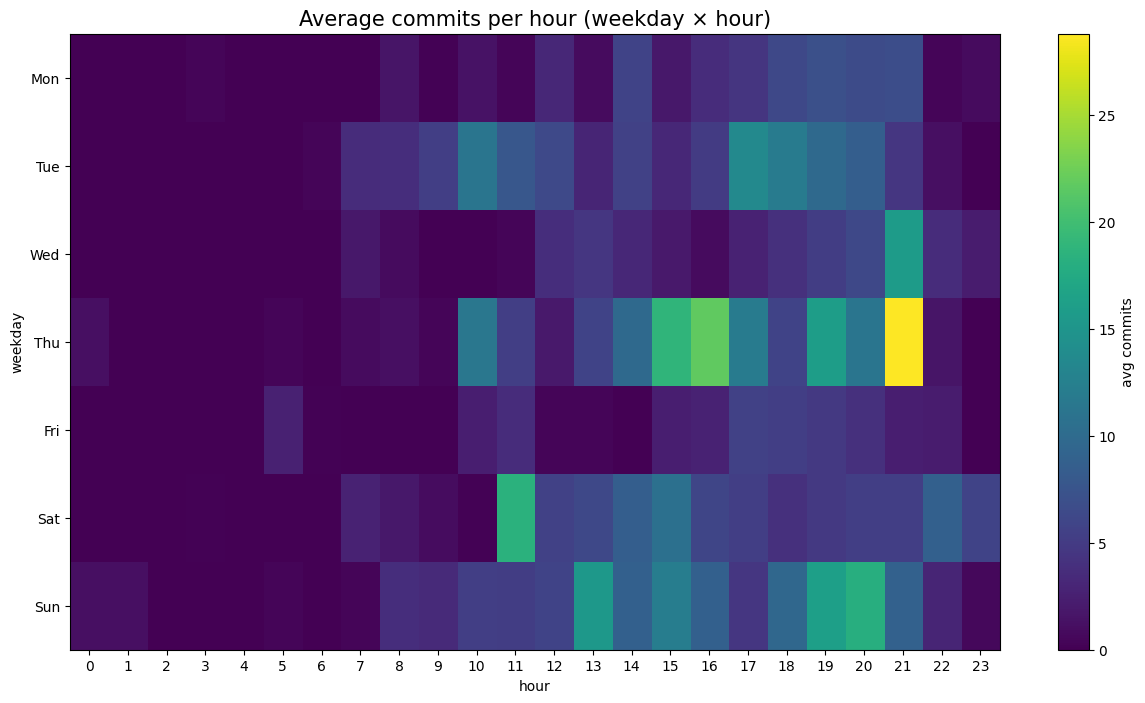

In [6]:
weekday_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

plt.figure(figsize=(15, 8))

# Plot the 2D array as an image (heatmap).
plt.imshow(avg_table.values, aspect="auto", origin="upper")

plt.title("Average commits per hour (weekday × hour)", fontsize=15)
plt.xlabel("hour")
plt.ylabel("weekday")

plt.xticks(range(24), range(24))
plt.yticks(range(7), weekday_names)

cbar = plt.colorbar()
cbar.set_label("avg commits")

plt.show()

## Find the busiest slot

We identify the (weekday, hour) cell with the highest average commits.

In [7]:
stacked = avg_table.stack()
best_weekday, best_hour = stacked.idxmax()
best_value = stacked.max()

best_weekday, best_hour, best_value

(3, 21, 28.8)

In [8]:
con.close()